正在检查文件: training_data/training.tif
总帧数: 41
图像尺寸: (1040, 1392)
数据类型: >u2
像素值范围: 3034 - 5804


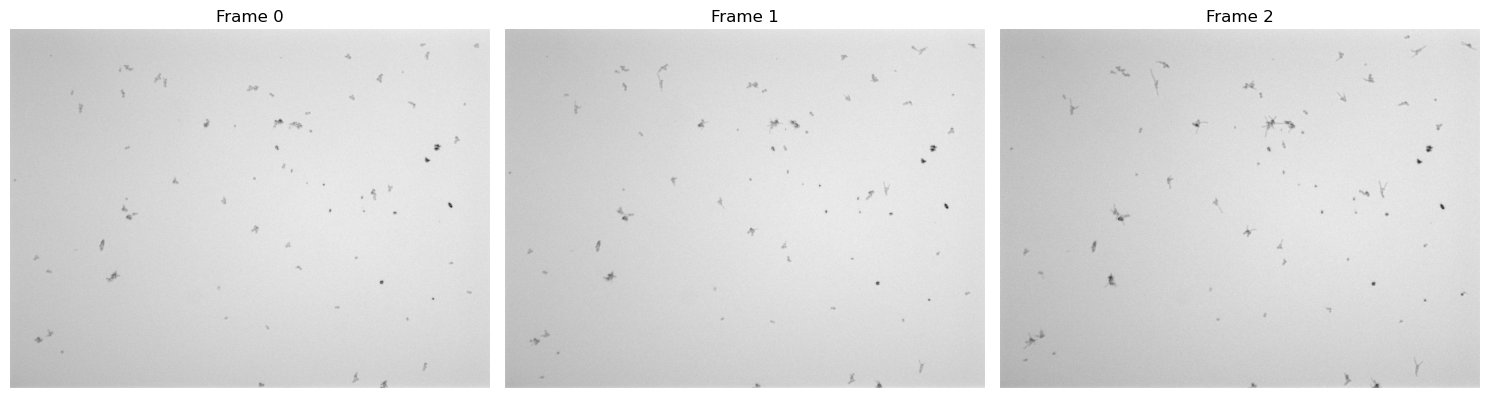

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def explore_single_tiff(tiff_path):
    """
    探索一个多层TIFF文件
    """
    print(f"正在检查文件: {tiff_path}")
    print("="*60)
    
    # 打开TIFF
    img = Image.open(tiff_path)
    
    # 获取帧数
    n_frames = img.n_frames
    print(f"总帧数: {n_frames}")
    
    # 查看第一帧
    img.seek(0)  # 跳到第0帧
    frame_0 = np.array(img)
    
    print(f"图像尺寸: {frame_0.shape}")
    print(f"数据类型: {frame_0.dtype}")
    print(f"像素值范围: {frame_0.min()} - {frame_0.max()}")
    
    # 可视化前几帧
    fig, axes = plt.subplots(1, min(3, n_frames), figsize=(15, 5))
    
    if n_frames == 1:
        axes = [axes]
    
    for i in range(min(3, n_frames)):
        img.seek(i)
        frame = np.array(img)
        axes[i].imshow(frame, cmap='gray')
        axes[i].set_title(f'Frame {i}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return n_frames, frame_0.shape

# 测试 - 用 training.tif
tiff_path = "training_data/training.tif"
n_frames, shape = explore_single_tiff(tiff_path)

In [2]:
import xml.etree.ElementTree as ET

def explore_xml(xml_path):
    """
    快速查看XML文件的基本信息
    """
    print(f"\n正在检查文件: {xml_path}")
    print("="*60)
    
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    # 统计信息
    all_tracks = root.findall('track')
    print(f"总标注数 (tracks): {len(all_tracks)}")
    
    # 统计每种细胞类型
    label_counts = {}
    frame_set = set()
    
    for track in all_tracks:
        label = track.get('label')
        label_counts[label] = label_counts.get(label, 0) + 1
        
        # 收集所有帧号
        for shape in track:
            frame = int(shape.get('frame'))
            frame_set.add(frame)
    
    print(f"\n细胞类型分布:")
    for label, count in label_counts.items():
        print(f"  {label}: {count}")
    
    print(f"\n标注的帧范围: {min(frame_set)} - {max(frame_set)}")
    print(f"标注的帧数: {len(frame_set)}")
    
    return frame_set, label_counts

# 测试
xml_path = "training_data/training.xml"
frames, labels = explore_xml(xml_path)


正在检查文件: training_data/training.xml
总标注数 (tracks): 1475

细胞类型分布:
  planktonic: 281
  hyphae: 359
  biofilm: 37
  single dispersed cell: 798

标注的帧范围: 0 - 26
标注的帧数: 27


In [3]:
def check_tiff_xml_match(tiff_path, xml_path):
    """
    检查TIFF和XML是否匹配
    """
    print("\n检查TIFF和XML的匹配情况")
    print("="*60)
    
    # 读取TIFF帧数
    img = Image.open(tiff_path)
    n_frames = img.n_frames
    
    # 读取XML的帧范围
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    frame_set = set()
    for track in root.findall('track'):
        for shape in track:
            frame = int(shape.get('frame'))
            frame_set.add(frame)
    
    print(f"TIFF总帧数: {n_frames}")
    print(f"XML标注的帧: {sorted(frame_set)}")
    print(f"标注帧数: {len(frame_set)}")
    
    # 检查是否有超出范围的标注
    max_annotated_frame = max(frame_set) if frame_set else -1
    
    if max_annotated_frame >= n_frames:
        print(f"⚠️ 警告: XML中有帧号({max_annotated_frame})超出TIFF范围({n_frames-1})")
    else:
        print(f"✓ 标注帧都在TIFF范围内")
    
    return frame_set

# 测试
tiff_path = "training_data/training.tif"
xml_path = "training_data/training.xml"
annotated_frames = check_tiff_xml_match(tiff_path, xml_path)


检查TIFF和XML的匹配情况
TIFF总帧数: 41
XML标注的帧: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
标注帧数: 27
✓ 标注帧都在TIFF范围内


In [4]:
import xml.etree.ElementTree as ET
import numpy as np
import cv2

def parse_annotations_for_frame(xml_path, frame_number):
    """
    解析XML，提取指定帧的所有标注
    
    参数:
        xml_path: XML文件路径
        frame_number: 要提取的帧号（CVAT从0开始）
    
    返回:
        annotations: 列表，包含该帧的所有标注
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    annotations = []
    
    # 遍历所有track
    for track in root.findall('track'):
        track_id = track.get('id')
        label = track.get('label')  # 细胞类型
        group_id = track.get('group_id')
        
        # 遍历track中的所有形状
        for shape in track:
            frame = int(shape.get('frame'))
            outside = int(shape.get('outside', 0))
            
            # 只处理我们要的帧，且不在外面的
            if frame == frame_number and outside == 0:
                shape_type = shape.tag  # ellipse, polygon, 或 polyline
                
                annotation = {
                    'track_id': track_id,
                    'label': label,
                    'shape_type': shape_type,
                    'group_id': group_id
                }
                
                # 根据形状类型提取坐标
                if shape_type == 'ellipse':
                    annotation['cx'] = float(shape.get('cx'))
                    annotation['cy'] = float(shape.get('cy'))
                    annotation['rx'] = float(shape.get('rx'))
                    annotation['ry'] = float(shape.get('ry'))
                
                elif shape_type == 'polygon':
                    points_str = shape.get('points')
                    # 格式: "x1,y1;x2,y2;x3,y3"
                    points = []
                    for point in points_str.split(';'):
                        x, y = point.split(',')
                        points.append([float(x), float(y)])
                    annotation['points'] = np.array(points)
                
                elif shape_type == 'polyline':
                    points_str = shape.get('points')
                    points = []
                    for point in points_str.split(';'):
                        x, y = point.split(',')
                        points.append([float(x), float(y)])
                    annotation['points'] = np.array(points)
                
                annotations.append(annotation)
    
    return annotations

# 测试：看看第0帧有什么
annotations_frame_0 = parse_annotations_for_frame("training_data/training.xml", 0)
print(f"第0帧有 {len(annotations_frame_0)} 个标注")

# 看看前3个标注
for i, ann in enumerate(annotations_frame_0[:3]):
    print(f"\n标注 {i+1}:")
    print(f"  类型: {ann['label']}")
    print(f"  形状: {ann['shape_type']}")
    if ann['shape_type'] == 'ellipse':
        print(f"  中心: ({ann['cx']:.1f}, {ann['cy']:.1f})")
        print(f"  半径: ({ann['rx']:.1f}, {ann['ry']:.1f})")

第0帧有 22 个标注

标注 1:
  类型: planktonic
  形状: ellipse
  中心: (141.2, 102.6)
  半径: (3.3, 3.8)

标注 2:
  类型: planktonic
  形状: ellipse
  中心: (146.4, 98.1)
  半径: (4.7, 5.0)

标注 3:
  类型: planktonic
  形状: ellipse
  中心: (98.7, 210.0)
  半径: (3.5, 4.1)


In [5]:
def create_mask(annotations, img_height, img_width):
    """
    从标注创建mask
    
    参数:
        annotations: 标注列表（从parse_annotations_for_frame获得）
        img_height: 图像高度
        img_width: 图像宽度
    
    返回:
        mask: numpy数组，每个像素值代表细胞类型
    """
    # 定义细胞类型到ID的映射
    cell_type_to_id = {
        'background': 0,
        'single dispersed cell': 1,
        'biofilm': 2,
        'hyphae': 3,
        'planktonic': 4
    }
    
    # 创建空白mask
    mask = np.zeros((img_height, img_width), dtype=np.uint8)
    
    # 遍历每个标注
    for ann in annotations:
        label = ann['label']
        class_id = cell_type_to_id.get(label, 0)
        
        if ann['shape_type'] == 'ellipse':
            # 画椭圆
            center = (int(ann['cx']), int(ann['cy']))
            axes = (int(ann['rx']), int(ann['ry']))
            cv2.ellipse(mask, center, axes, 0, 0, 360, class_id, -1)
            
        elif ann['shape_type'] == 'polygon':
            # 画多边形（填充）
            points = ann['points'].astype(np.int32)
            cv2.fillPoly(mask, [points], class_id)
            
        elif ann['shape_type'] == 'polyline':
            # 画折线（菌丝）
            points = ann['points'].astype(np.int32)
            cv2.polylines(mask, [points], False, class_id, thickness=2)
    
    return mask

# 测试：为第0帧创建mask
annotations_frame_0 = parse_annotations_for_frame("training_data/training.xml", 0)
mask_frame_0 = create_mask(annotations_frame_0, 1040, 1392)

print(f"Mask尺寸: {mask_frame_0.shape}")
print(f"Mask中的类别: {np.unique(mask_frame_0)}")

# 统计每个类别的像素数
for class_id in np.unique(mask_frame_0):
    count = np.sum(mask_frame_0 == class_id)
    print(f"类别 {class_id}: {count} 像素")

Mask尺寸: (1040, 1392)
Mask中的类别: [0 4]
类别 0: 1446647 像素
类别 4: 1033 像素


/var/folders/wp/l8c79r0x3rd_31sm3pkk2ccc0000gn/T/ipykernel_62102/2882905059.py:48: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/wp/l8c79r0x3rd_31sm3pkk2ccc0000gn/T/ipykernel_62102/2882905059.py:48: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/wp/l8c79r0x3rd_31sm3pkk2ccc0000gn/T/ipykernel_62102/2882905059.py:48: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/wp/l8c79r0x3rd_31sm3pkk2ccc0000gn/T/ipykernel_62102/2882905059.py:48: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/wp/l8c79r0x3rd_31sm3pkk2ccc0000gn/T/ipykernel_62102/2882905059.py:48: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/wp/l8c7

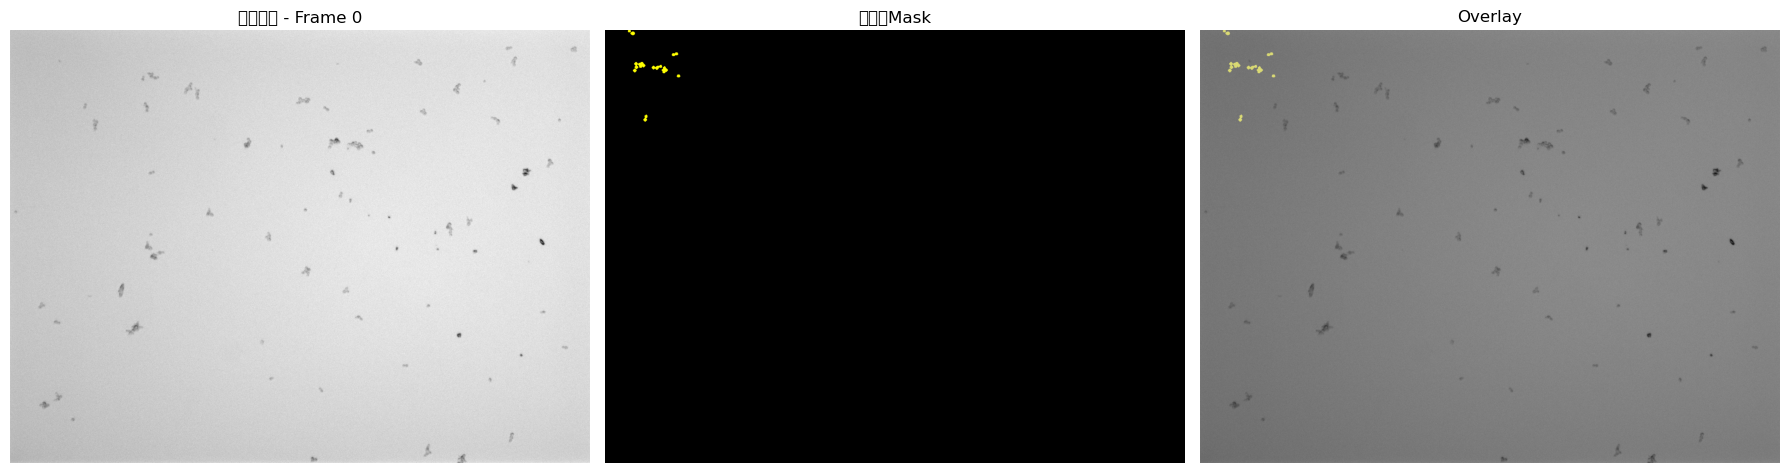

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

def visualize_frame_and_mask(tiff_path, mask, frame_number):
    """
    可视化原始图像和生成的mask
    """
    # 读取原始图像的指定帧
    img = Image.open(tiff_path)
    img.seek(frame_number)
    original_frame = np.array(img)
    
    # 创建彩色mask用于可视化
    colors = {
        0: [0, 0, 0],        # background - 黑色
        1: [255, 0, 0],      # single dispersed cell - 红色
        2: [0, 255, 0],      # biofilm - 绿色
        3: [0, 0, 255],      # hyphae - 蓝色
        4: [255, 255, 0]     # planktonic - 黄色
    }
    
    colored_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in colors.items():
        colored_mask[mask == class_id] = color
    
    # 显示
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(original_frame, cmap='gray')
    axes[0].set_title(f'原始图像 - Frame {frame_number}')
    axes[0].axis('off')
    
    axes[1].imshow(colored_mask)
    axes[1].set_title('生成的Mask')
    axes[1].axis('off')
    
    # Overlay
    # 先把原始图像归一化到0-255
    normalized = ((original_frame - original_frame.min()) / 
                  (original_frame.max() - original_frame.min()) * 255).astype(np.uint8)
    rgb_frame = cv2.cvtColor(normalized, cv2.COLOR_GRAY2RGB)
    overlay = cv2.addWeighted(rgb_frame, 0.6, colored_mask, 0.4, 0)
    
    axes[2].imshow(overlay)
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# 测试：可视化第0帧
visualize_frame_and_mask("training_data/training.tif", mask_frame_0, 0)

In [7]:
from pathlib import Path
from PIL import Image
import numpy as np
import cv2

class DatasetProcessor:
    """
    处理TIFF+XML，生成训练数据
    """
    def __init__(self, output_dir="processed_data"):
        self.output_dir = Path(output_dir)
        self.cell_type_to_id = {
            'background': 0,
            'single dispersed cell': 1,
            'biofilm': 2,
            'hyphae': 3,
            'planktonic': 4
        }
    
    def parse_annotations_for_frame(self, xml_path, frame_number):
        """解析指定帧的标注（之前写的函数）"""
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        annotations = []
        
        for track in root.findall('track'):
            track_id = track.get('id')
            label = track.get('label')
            group_id = track.get('group_id')
            
            for shape in track:
                frame = int(shape.get('frame'))
                outside = int(shape.get('outside', 0))
                
                if frame == frame_number and outside == 0:
                    shape_type = shape.tag
                    
                    annotation = {
                        'track_id': track_id,
                        'label': label,
                        'shape_type': shape_type,
                        'group_id': group_id
                    }
                    
                    if shape_type == 'ellipse':
                        annotation['cx'] = float(shape.get('cx'))
                        annotation['cy'] = float(shape.get('cy'))
                        annotation['rx'] = float(shape.get('rx'))
                        annotation['ry'] = float(shape.get('ry'))
                    
                    elif shape_type in ['polygon', 'polyline']:
                        points_str = shape.get('points')
                        points = []
                        for point in points_str.split(';'):
                            x, y = point.split(',')
                            points.append([float(x), float(y)])
                        annotation['points'] = np.array(points)
                    
                    annotations.append(annotation)
        
        return annotations
    
    def create_mask(self, annotations, img_height, img_width):
        """创建mask（之前写的函数）"""
        mask = np.zeros((img_height, img_width), dtype=np.uint8)
        
        for ann in annotations:
            label = ann['label']
            class_id = self.cell_type_to_id.get(label, 0)
            
            if ann['shape_type'] == 'ellipse':
                center = (int(ann['cx']), int(ann['cy']))
                axes = (int(ann['rx']), int(ann['ry']))
                cv2.ellipse(mask, center, axes, 0, 0, 360, class_id, -1)
                
            elif ann['shape_type'] == 'polygon':
                points = ann['points'].astype(np.int32)
                cv2.fillPoly(mask, [points], class_id)
                
            elif ann['shape_type'] == 'polyline':
                points = ann['points'].astype(np.int32)
                cv2.polylines(mask, [points], False, class_id, thickness=2)
        
        return mask
    
    def get_annotated_frames(self, xml_path):
        """获取XML中所有被标注的帧号"""
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        frame_set = set()
        for track in root.findall('track'):
            for shape in track:
                frame = int(shape.get('frame'))
                outside = int(shape.get('outside', 0))
                if outside == 0:  # 只计算不在外面的
                    frame_set.add(frame)
        
        return sorted(frame_set)
    
    def process_single_sample(self, tiff_path, xml_path, sample_name):
        """
        处理一个完整的样本
        
        参数:
            tiff_path: TIFF文件路径
            xml_path: XML文件路径
            sample_name: 样本名称（用于文件夹命名）
        """
        print(f"\n{'='*60}")
        print(f"处理样本: {sample_name}")
        print(f"{'='*60}")
        
        # 创建输出目录
        sample_dir = self.output_dir / sample_name
        images_dir = sample_dir / "images"
        masks_dir = sample_dir / "masks"
        
        images_dir.mkdir(parents=True, exist_ok=True)
        masks_dir.mkdir(parents=True, exist_ok=True)
        
        # 打开TIFF
        img = Image.open(tiff_path)
        n_frames = img.n_frames
        
        # 获取标注的帧
        annotated_frames = self.get_annotated_frames(xml_path)
        
        print(f"TIFF总帧数: {n_frames}")
        print(f"标注的帧数: {len(annotated_frames)}")
        print(f"标注的帧: {annotated_frames[:10]}{'...' if len(annotated_frames) > 10 else ''}")
        
        # 处理每一帧
        for frame_num in annotated_frames:
            # 读取图像帧
            img.seek(frame_num)
            frame = np.array(img)
            
            # 解析标注
            annotations = self.parse_annotations_for_frame(xml_path, frame_num)
            
            # 创建mask
            mask = self.create_mask(annotations, frame.shape[0], frame.shape[1])
            
            # 保存
            frame_filename = f"frame_{frame_num:04d}.png"
            
            # 保存图像（归一化到0-255）
            # 16位 -> 8位，保留对比度
            normalized = ((frame - frame.min()) / (frame.max() - frame.min()) * 255).astype(np.uint8)
            cv2.imwrite(str(images_dir / frame_filename), normalized)
            
            # 保存mask
            cv2.imwrite(str(masks_dir / frame_filename), mask)
            
            if (frame_num + 1) % 5 == 0:
                print(f"  处理进度: {frame_num + 1}/{len(annotated_frames)} 帧")
        
        print(f"✓ 完成! 保存到: {sample_dir}")
        print(f"  图像: {len(annotated_frames)} 张")
        print(f"  Masks: {len(annotated_frames)} 张")
        
        return len(annotated_frames)

# 初始化处理器
processor = DatasetProcessor(output_dir="processed_data")

# 处理 training 样本
n_processed = processor.process_single_sample(
    tiff_path="training_data/training.tif",
    xml_path="training_data/training.xml",
    sample_name="training"
)



处理样本: training
TIFF总帧数: 41
标注的帧数: 26
标注的帧: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
  处理进度: 5/26 帧
  处理进度: 10/26 帧
  处理进度: 15/26 帧
  处理进度: 20/26 帧
  处理进度: 25/26 帧
✓ 完成! 保存到: processed_data/training
  图像: 26 张
  Masks: 26 张


In [8]:
def process_all_samples(data_dir="training_data", output_dir="processed_data"):
    """
    批量处理文件夹中的所有TIFF+XML配对
    """
    data_path = Path(data_dir)
    
    # 找到所有的TIFF文件
    tiff_files = list(data_path.glob("*.tif"))
    
    print(f"找到 {len(tiff_files)} 个TIFF文件")
    print("="*60)
    
    processor = DatasetProcessor(output_dir=output_dir)
    
    summary = []
    
    for tiff_file in tiff_files:
        # 构建对应的XML文件路径
        xml_file = tiff_file.with_suffix('.xml')
        
        # 检查XML是否存在
        if not xml_file.exists():
            print(f"⚠️  跳过 {tiff_file.name}: 找不到对应的XML文件")
            continue
        
        # 获取样本名称（去掉.tif扩展名）
        sample_name = tiff_file.stem
        
        try:
            # 处理这个样本
            n_frames = processor.process_single_sample(
                tiff_path=str(tiff_file),
                xml_path=str(xml_file),
                sample_name=sample_name
            )
            
            summary.append({
                'sample': sample_name,
                'frames': n_frames,
                'status': 'success'
            })
            
        except Exception as e:
            print(f"❌ 处理 {sample_name} 时出错: {str(e)}")
            summary.append({
                'sample': sample_name,
                'frames': 0,
                'status': f'error: {str(e)}'
            })
    
    # 打印总结
    print("\n" + "="*60)
    print("处理完成！总结:")
    print("="*60)
    
    total_frames = 0
    for item in summary:
        status_symbol = "✓" if item['status'] == 'success' else "❌"
        print(f"{status_symbol} {item['sample']}: {item['frames']} 帧")
        if item['status'] == 'success':
            total_frames += item['frames']
    
    print(f"\n总计: {total_frames} 帧图像对")
    print(f"保存位置: {output_dir}/")
    
    return summary

# 运行批量处理
summary = process_all_samples(
    data_dir="training_data",
    output_dir="processed_data"
)

找到 5 个TIFF文件

处理样本: MattLines_1
TIFF总帧数: 41
标注的帧数: 17
标注的帧: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
  处理进度: 5/17 帧
  处理进度: 10/17 帧
  处理进度: 15/17 帧
✓ 完成! 保存到: processed_data/MattLines_1
  图像: 17 张
  Masks: 17 张

处理样本: MattLines27
TIFF总帧数: 41
标注的帧数: 4
标注的帧: [4, 15, 16, 40]
  处理进度: 5/4 帧
✓ 完成! 保存到: processed_data/MattLines27
  图像: 4 张
  Masks: 4 张

处理样本: MattLines_7
TIFF总帧数: 41
标注的帧数: 17
标注的帧: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
  处理进度: 5/17 帧
  处理进度: 10/17 帧
  处理进度: 15/17 帧
✓ 完成! 保存到: processed_data/MattLines_7
  图像: 17 张
  Masks: 17 张

处理样本: training
TIFF总帧数: 41
标注的帧数: 26
标注的帧: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
  处理进度: 5/26 帧
  处理进度: 10/26 帧
  处理进度: 15/26 帧
  处理进度: 20/26 帧
  处理进度: 25/26 帧
✓ 完成! 保存到: processed_data/training
  图像: 26 张
  Masks: 26 张

处理样本: LizaMutant38
TIFF总帧数: 41
标注的帧数: 10
标注的帧: [0, 1, 2, 3, 4, 5, 18, 19, 22, 40]
  处理进度: 5/10 帧
  处理进度: 20/10 帧
✓ 完成! 保存到: processed_data/LizaMutant38
  图像: 10 张
  Masks: 10 张

处理完成！总结:
✓ MattLines_1: 17 帧
✓ MattLines27: 4 帧
✓ MattLines_7: 17 帧
✓ tr

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
import json

def create_dataset_splits(processed_dir="processed_data", output_file="dataset_info.csv"):
    """
    创建数据集划分（train/val/test）
    """
    processed_path = Path(processed_dir)
    
    # 收集所有的image-mask对
    data_pairs = []
    
    for sample_dir in processed_path.iterdir():
        if sample_dir.is_dir():
            sample_name = sample_dir.name
            images_dir = sample_dir / "images"
            masks_dir = sample_dir / "masks"
            
            if images_dir.exists() and masks_dir.exists():
                # 获取所有图像文件
                image_files = sorted(images_dir.glob("*.png"))
                
                for img_file in image_files:
                    mask_file = masks_dir / img_file.name
                    
                    if mask_file.exists():
                        data_pairs.append({
                            'sample': sample_name,
                            'frame_id': img_file.stem,  # frame_0000
                            'image_path': str(img_file),
                            'mask_path': str(mask_file)
                        })
    
    print(f"收集到 {len(data_pairs)} 对图像-mask")
    
    # 创建DataFrame
    df = pd.DataFrame(data_pairs)
    
    # 按样本分组统计
    print("\n每个样本的帧数:")
    print(df.groupby('sample').size())
    
    # 划分数据集
    # 70% 训练，15% 验证，15% 测试
    train_val, test = train_test_split(df, test_size=0.15, random_state=42)
    train, val = train_test_split(train_val, test_size=0.176, random_state=42)  # 0.176 ≈ 0.15/0.85
    
    # 添加split标记
    train['split'] = 'train'
    val['split'] = 'val'
    test['split'] = 'test'
    
    # 合并
    final_df = pd.concat([train, val, test], ignore_index=True)
    
    # 保存
    final_df.to_csv(output_file, index=False)
    
    # 打印统计
    print("\n" + "="*60)
    print("数据集划分统计:")
    print("="*60)
    print(f"训练集: {len(train)} 帧 ({len(train)/len(final_df)*100:.1f}%)")
    print(f"验证集: {len(val)} 帧 ({len(val)/len(final_df)*100:.1f}%)")
    print(f"测试集: {len(test)} 帧 ({len(test)/len(final_df)*100:.1f}%)")
    print(f"总计: {len(final_df)} 帧")
    
    # 每个split中各样本的分布
    print("\n各split中的样本分布:")
    print(final_df.groupby(['split', 'sample']).size().unstack(fill_value=0))
    
    # 保存统计信息
    stats = {
        'total_frames': len(final_df),
        'train_frames': len(train),
        'val_frames': len(val),
        'test_frames': len(test),
        'samples': df.groupby('sample').size().to_dict()
    }
    
    with open('dataset_stats.json', 'w') as f:
        json.dump(stats, f, indent=2)
    
    print(f"\n✓ 数据集信息保存到: {output_file}")
    print(f"✓ 统计信息保存到: dataset_stats.json")
    
    return final_df

# 创建数据集划分
df = create_dataset_splits(
    processed_dir="processed_data",
    output_file="dataset_info.csv"
)

# 查看前几行
print("\n数据集预览:")
print(df.head(10))

收集到 74 对图像-mask

每个样本的帧数:
sample
LizaMutant38    10
MattLines27      4
MattLines_1     17
MattLines_7     17
training        26
dtype: int64

数据集划分统计:
训练集: 51 帧 (68.9%)
验证集: 11 帧 (14.9%)
测试集: 12 帧 (16.2%)
总计: 74 帧

各split中的样本分布:
sample  LizaMutant38  MattLines27  MattLines_1  MattLines_7  training
split                                                                
test               2            1            3            1         5
train              7            2           12           14        16
val                1            1            2            2         5

✓ 数据集信息保存到: dataset_info.csv
✓ 统计信息保存到: dataset_stats.json

数据集预览:
         sample    frame_id  \
0      training  frame_0016   
1  LizaMutant38  frame_0004   
2      training  frame_0007   
3   MattLines_7  frame_0011   
4   MattLines_7  frame_0003   
5      training  frame_0022   
6   MattLines_7  frame_0004   
7      training  frame_0021   
8   MattLines27  frame_0004   
9   MattLines_1  frame_0007   

           

✓ 验证图保存到: dataset_verification.png


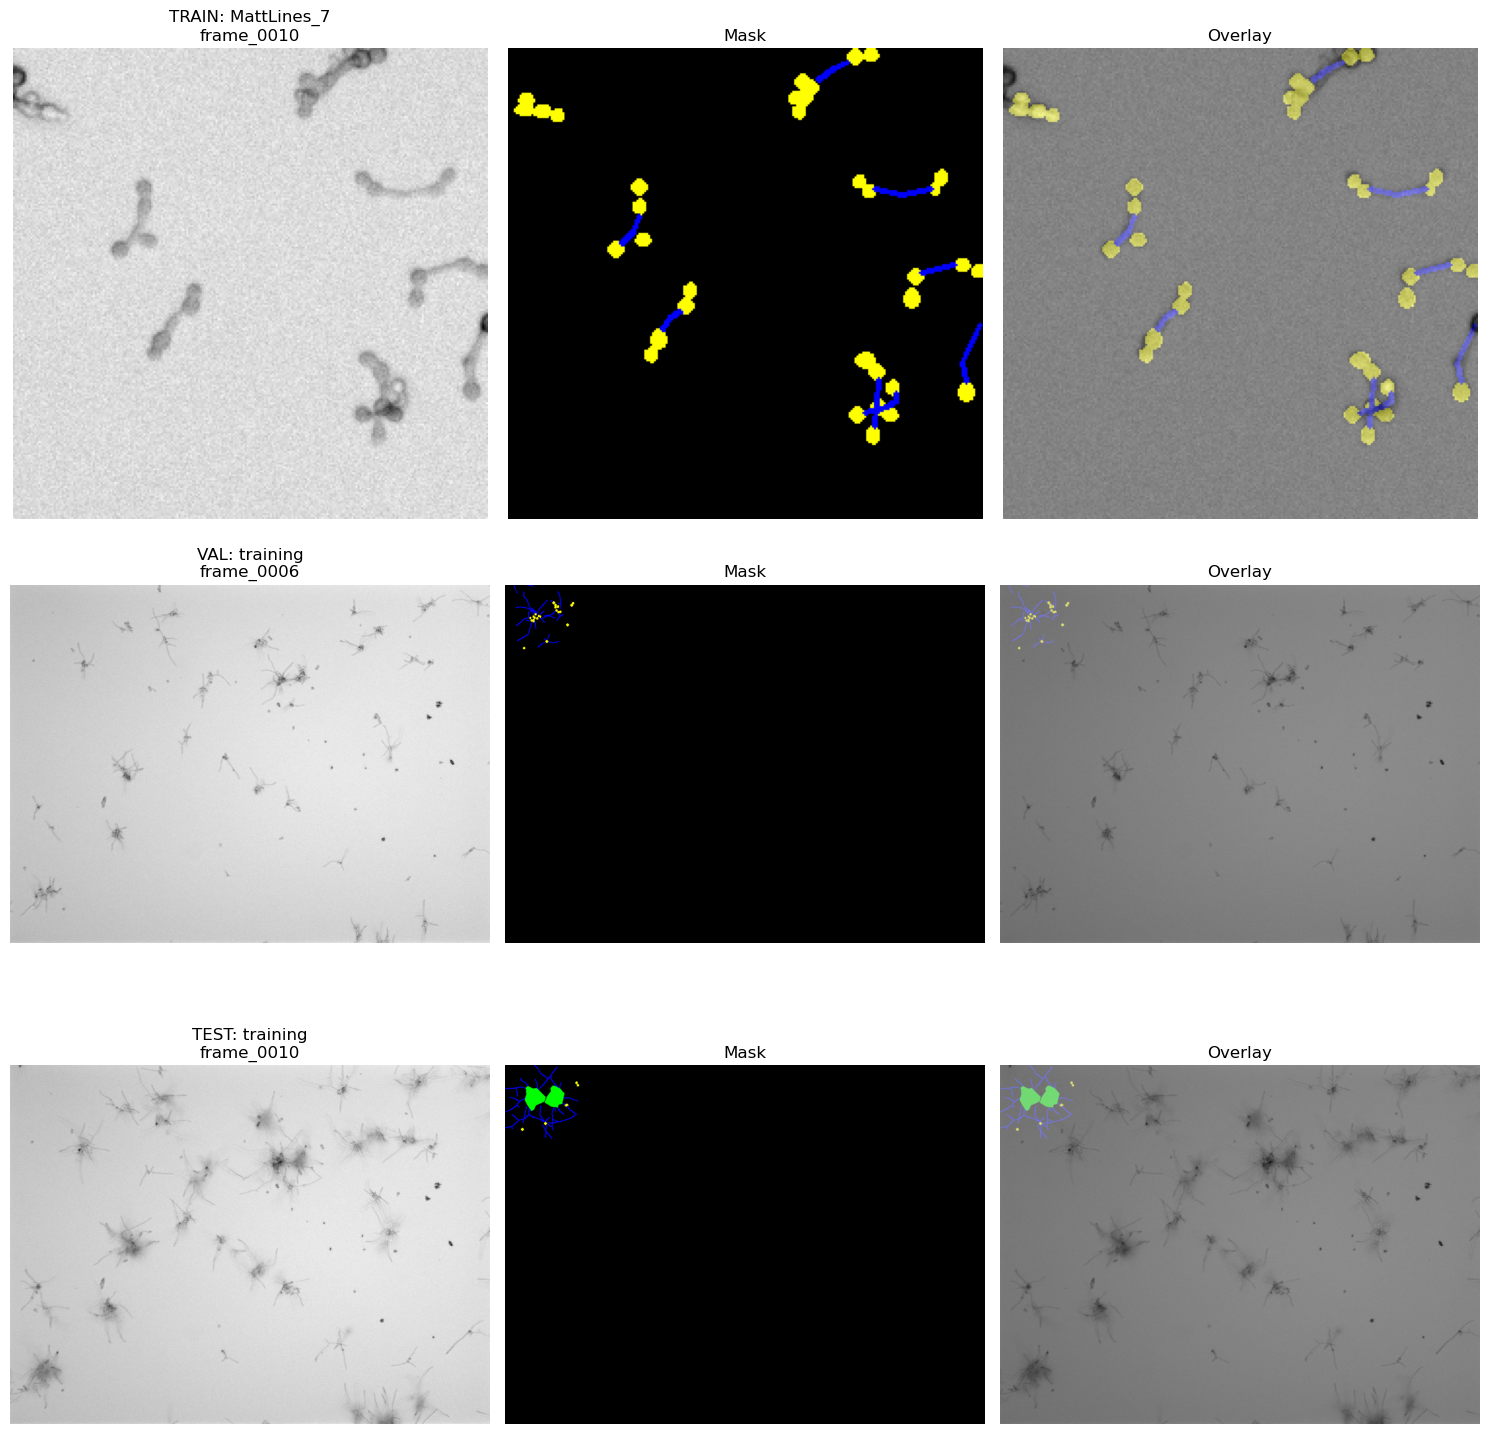

In [10]:
def verify_dataset(csv_file="dataset_info.csv", num_samples=3):
    """
    随机抽取几个样本进行可视化验证
    """
    df = pd.read_csv(csv_file)
    
    # 从每个split中随机抽取一个
    samples_to_check = []
    for split in ['train', 'val', 'test']:
        split_df = df[df['split'] == split]
        if len(split_df) > 0:
            sample = split_df.sample(1).iloc[0]
            samples_to_check.append(sample)
    
    # 可视化
    fig, axes = plt.subplots(len(samples_to_check), 3, figsize=(15, 5*len(samples_to_check)))
    
    if len(samples_to_check) == 1:
        axes = axes.reshape(1, -1)
    
    for i, sample in enumerate(samples_to_check):
        # 读取图像和mask
        img = cv2.imread(sample['image_path'], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(sample['mask_path'], cv2.IMREAD_GRAYSCALE)
        
        # 创建彩色mask
        colors = {
            0: [0, 0, 0],
            1: [255, 0, 0],
            2: [0, 255, 0],
            3: [0, 0, 255],
            4: [255, 255, 0]
        }
        
        colored_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
        for class_id, color in colors.items():
            colored_mask[mask == class_id] = color
        
        # 显示
        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title(f'{sample["split"].upper()}: {sample["sample"]}\n{sample["frame_id"]}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(colored_mask)
        axes[i, 1].set_title('Mask')
        axes[i, 1].axis('off')
        
        # Overlay
        rgb_img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        overlay = cv2.addWeighted(rgb_img, 0.6, colored_mask, 0.4, 0)
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('dataset_verification.png', dpi=150, bbox_inches='tight')
    print("✓ 验证图保存到: dataset_verification.png")
    plt.show()

# 验证
verify_dataset("dataset_info.csv")

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_dataset(csv_file="dataset_info.csv"):
    """
    分析整个数据集的类别分布
    """
    df = pd.read_csv(csv_file)
    
    print("="*60)
    print("数据集类别分布分析")
    print("="*60)
    
    # 类别名称映射
    class_names = {
        0: 'background',
        1: 'single dispersed cell',
        2: 'biofilm',
        3: 'hyphae',
        4: 'planktonic'
    }
    
    # 统计每个split的类别分布
    split_stats = {}
    
    for split in ['train', 'val', 'test']:
        split_df = df[df['split'] == split]
        
        class_pixel_counts = {i: 0 for i in range(5)}
        total_pixels = 0
        
        print(f"\n{split.upper()} SET ({len(split_df)} 帧):")
        print("-"*60)
        
        for _, row in split_df.iterrows():
            mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)
            
            # 统计每个类别
            for class_id in range(5):
                count = np.sum(mask == class_id)
                class_pixel_counts[class_id] += count
                total_pixels += count
        
        # 打印统计
        split_stats[split] = {}
        for class_id, count in class_pixel_counts.items():
            percentage = (count / total_pixels * 100) if total_pixels > 0 else 0
            split_stats[split][class_id] = {
                'count': count,
                'percentage': percentage
            }
            print(f"  {class_names[class_id]:25s}: {count:>12,} pixels ({percentage:>5.2f}%)")
        
        print(f"  {'TOTAL':25s}: {total_pixels:>12,} pixels")
    
    return split_stats

# 运行分析
split_stats = analyze_dataset("dataset_info.csv")

数据集类别分布分析

TRAIN SET (51 帧):
------------------------------------------------------------
  background               :   36,989,268 pixels (98.04%)
  single dispersed cell    :       14,518 pixels ( 0.04%)
  biofilm                  :      574,087 pixels ( 1.52%)
  hyphae                   :       37,221 pixels ( 0.10%)
  planktonic               :      112,154 pixels ( 0.30%)
  TOTAL                    :   37,727,248 pixels

VAL SET (11 帧):
------------------------------------------------------------
  background               :    9,785,086 pixels (94.36%)
  single dispersed cell    :        2,761 pixels ( 0.03%)
  biofilm                  :      503,966 pixels ( 4.86%)
  hyphae                   :       60,157 pixels ( 0.58%)
  planktonic               :       17,982 pixels ( 0.17%)
  TOTAL                    :   10,369,952 pixels

TEST SET (12 帧):
------------------------------------------------------------
  background               :   11,040,165 pixels (93.42%)
  single disperse


✓ 类别分布图保存到: class_distribution_analysis.png


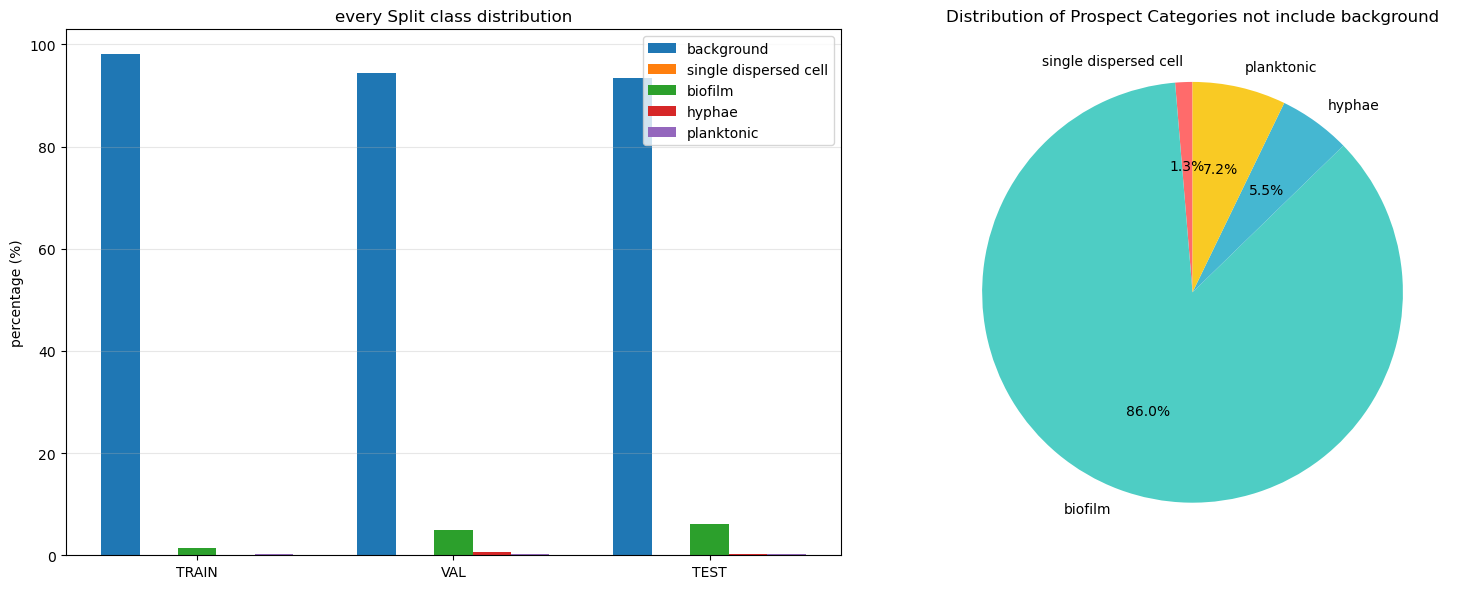


类别不平衡分析:

前景类别（不含background）:
  single dispersed cell    : 不平衡比率 = 65.07x
  biofilm                  : 不平衡比率 = 1.00x
  hyphae                   : 不平衡比率 = 15.50x
  planktonic               : 不平衡比率 = 11.98x

最大不平衡比率: 65.07x
⚠️  建议: 类别严重不平衡! 训练时应使用加权loss


In [28]:
def visualize_class_distribution(split_stats):
    """
    可视化类别分布
    """
    class_names = {
        0: 'background',
        1: 'single dispersed cell',
        2: 'biofilm',
        3: 'hyphae',
        4: 'planktonic'
    }
    
    # 准备数据
    splits = ['train', 'val', 'test']
    class_ids = [0, 1, 2, 3, 4]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. 各split的类别分布（百分比）
    data_percentage = []
    for split in splits:
        percentages = [split_stats[split][cid]['percentage'] for cid in class_ids]
        data_percentage.append(percentages)
    
    data_percentage = np.array(data_percentage).T
    
    x = np.arange(len(splits))
    width = 0.15
    
    for i, class_id in enumerate(class_ids):
        offset = width * (i - 2)
        axes[0].bar(x + offset, data_percentage[i], width, 
                   label=class_names[class_id])
    
    axes[0].set_ylabel('percentage (%)')
    axes[0].set_title('every Split class distribution')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([s.upper() for s in splits])
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # 2. 整体类别分布（饼图）
    total_counts = {cid: 0 for cid in class_ids}
    for split in splits:
        for cid in class_ids:
            total_counts[cid] += split_stats[split][cid]['count']
    
    # 去掉background，只看前景类
    foreground_counts = {cid: total_counts[cid] for cid in [1, 2, 3, 4]}
    
    labels = [class_names[cid] for cid in foreground_counts.keys()]
    sizes = list(foreground_counts.values())
    colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#f9ca24']
    
    axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
               startangle=90)
    axes[1].set_title('Distribution of Prospect Categories not include background')
    
    plt.tight_layout()
    plt.savefig('class_distribution_analysis.png', dpi=150, bbox_inches='tight')
    print("\n✓ 类别分布图保存到: class_distribution_analysis.png")
    plt.show()
    
    # 计算类别不平衡比率
    print("\n" + "="*60)
    print("类别不平衡分析:")
    print("="*60)
    
    foreground_total = sum(foreground_counts.values())
    max_count = max(foreground_counts.values())
    
    print("\n前景类别（不含background）:")
    for cid in [1, 2, 3, 4]:
        count = foreground_counts[cid]
        ratio = max_count / count if count > 0 else 0
        print(f"  {class_names[cid]:25s}: 不平衡比率 = {ratio:.2f}x")
    
    # 推荐是否需要加权
    max_ratio = max([max_count / foreground_counts[cid] 
                     for cid in [1, 2, 3, 4] if foreground_counts[cid] > 0])
    
    print(f"\n最大不平衡比率: {max_ratio:.2f}x")
    
    if max_ratio > 10:
        print("⚠️  建议: 类别严重不平衡! 训练时应使用加权loss")
    elif max_ratio > 5:
        print("⚠️  建议: 类别中度不平衡，建议使用加权loss或数据增强")
    else:
        print("✓ 类别相对平衡")

# 可视化
visualize_class_distribution(split_stats)

In [13]:
def calculate_class_weights(split_stats, method='inverse_frequency'):
    """
    计算类别权重，用于加权loss
    
    method:
        - 'inverse_frequency': 1 / frequency
        - 'effective_samples': 更平滑的权重计算
    """
    # 使用训练集统计
    train_stats = split_stats['train']
    
    # 只计算前景类的权重（background权重设为0或很小）
    class_counts = {cid: train_stats[cid]['count'] for cid in [1, 2, 3, 4]}
    
    if method == 'inverse_frequency':
        # 方法1: 反频率
        total = sum(class_counts.values())
        weights = {}
        for cid, count in class_counts.items():
            weights[cid] = total / (len(class_counts) * count)
        
        # 归一化，使得最小权重为1
        min_weight = min(weights.values())
        weights = {cid: w / min_weight for cid, w in weights.items()}
    
    elif method == 'effective_samples':
        # 方法2: Effective Number of Samples
        # 更平滑的权重，避免极端值
        beta = 0.9999
        effective_num = {cid: (1 - beta**count) / (1 - beta) 
                         for cid, count in class_counts.items()}
        weights = {cid: 1.0 / en for cid, en in effective_num.items()}
        
        # 归一化
        min_weight = min(weights.values())
        weights = {cid: w / min_weight for cid, w in weights.items()}
    
    # background权重设为很小的值
    weights[0] = 0.1
    
    print("="*60)
    print(f"类别权重 (方法: {method}):")
    print("="*60)
    
    class_names = {
        0: 'background',
        1: 'single dispersed cell',
        2: 'biofilm',
        3: 'hyphae',
        4: 'planktonic'
    }
    
    for cid in [0, 1, 2, 3, 4]:
        print(f"  {class_names[cid]:25s}: {weights[cid]:.2f}")
    
    # 转换为PyTorch tensor格式
    weight_tensor = [weights[i] for i in range(5)]
    
    print(f"\nPyTorch权重向量: {weight_tensor}")
    print("\n使用方法:")
    print("  criterion = nn.CrossEntropyLoss(weight=torch.tensor([...]))")
    
    return weights, weight_tensor

# 计算两种方法的权重
print("方法1: 反频率")
weights_inv, tensor_inv = calculate_class_weights(split_stats, method='inverse_frequency')

print("\n" + "="*60 + "\n")

print("方法2: Effective Samples")
weights_eff, tensor_eff = calculate_class_weights(split_stats, method='effective_samples')

方法1: 反频率
类别权重 (方法: inverse_frequency):
  background               : 0.10
  single dispersed cell    : 39.54
  biofilm                  : 1.00
  hyphae                   : 15.42
  planktonic               : 5.12

PyTorch权重向量: [0.1, 39.54311888689902, 1.0, 15.423739286961665, 5.118738520248944]

使用方法:
  criterion = nn.CrossEntropyLoss(weight=torch.tensor([...]))


方法2: Effective Samples
类别权重 (方法: effective_samples):
  background               : 0.10
  single dispersed cell    : 1.31
  biofilm                  : 1.00
  hyphae                   : 1.02
  planktonic               : 1.00

PyTorch权重向量: [0.1, 1.3057070853285222, 1.0, 1.0247777207573967, 1.0000134578584705]

使用方法:
  criterion = nn.CrossEntropyLoss(weight=torch.tensor([...]))


In [19]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import pandas as pd
import numpy as np

class CellSegmentationDataset(Dataset):
    def __init__(self, csv_file, split='train', augment=False, img_size=(256, 256)):
        """
        参数:
            csv_file: CSV文件路径
            split: 'train', 'val', 或 'test'
            augment: 是否使用数据增强
            img_size: 统一的图像尺寸 (height, width)
        """
        self.df = pd.read_csv(csv_file)
        self.df = self.df[self.df['split'] == split].reset_index(drop=True)
        self.augment = augment
        self.img_size = img_size  # 新增：统一尺寸
        print(f"{split.upper()} dataset: {len(self.df)} 张图像 (resize到 {img_size})")
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        mask_path = self.df.iloc[idx]['mask_path']
        
        # 读取图像和mask
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # **关键：Resize到统一尺寸**
        image = cv2.resize(image, (self.img_size[1], self.img_size[0]), 
                          interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.img_size[1], self.img_size[0]), 
                         interpolation=cv2.INTER_NEAREST)  # mask用最近邻插值
        
        # 简单的数据增强（如果是训练集）
        if self.augment:
            # 随机水平翻转
            if np.random.rand() > 0.5:
                image = np.fliplr(image).copy()
                mask = np.fliplr(mask).copy()
            
            # 随机垂直翻转
            if np.random.rand() > 0.5:
                image = np.flipud(image).copy()
                mask = np.flipud(mask).copy()
            
            # 随机旋转90度
            k = np.random.randint(0, 4)
            if k > 0:
                image = np.rot90(image, k).copy()
                mask = np.rot90(mask, k).copy()
        
        # 归一化图像到[-1, 1]
        image = (image / 255.0 - 0.5) / 0.5
        
        # 转换为tensor
        image = torch.from_numpy(image).float().unsqueeze(0)  # (1, H, W)
        mask = torch.from_numpy(mask).long()  # (H, W)
        
        return image, mask


def create_dataloaders(batch_size=4, img_size=(256, 256), num_workers=0):
    """
    创建DataLoader
    
    参数:
        batch_size: batch大小
        img_size: 图像resize尺寸 (height, width)
        num_workers: 数据加载线程数
    """
    train_dataset = CellSegmentationDataset(
        'dataset_info.csv', 
        'train', 
        augment=True,
        img_size=img_size
    )
    val_dataset = CellSegmentationDataset(
        'dataset_info.csv', 
        'val', 
        augment=False,
        img_size=img_size
    )
    test_dataset = CellSegmentationDataset(
        'dataset_info.csv', 
        'test', 
        augment=False,
        img_size=img_size
    )
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=num_workers,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers,
        pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers,
        pin_memory=True
    )
    
    return train_loader, val_loader, test_loader


# 测试 - 使用256x256的尺寸
print("创建DataLoaders (resize到256x256)...")
train_loader, val_loader, test_loader = create_dataloaders(
    batch_size=4, 
    img_size=(256, 256),  # 你可以改成 (512, 512) 如果显存够
    num_workers=0
)

print(f"\nDataLoader信息:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# 测试读取一个batch
print("\n测试读取batch:")
for images, masks in train_loader:
    print(f"  Images shape: {images.shape}")  # 应该是 (4, 1, 256, 256)
    print(f"  Masks shape: {masks.shape}")    # 应该是 (4, 256, 256)
    print(f"  Image range: [{images.min():.2f}, {images.max():.2f}]")
    print(f"  Mask classes: {torch.unique(masks).tolist()}")
    break

print("\n✓ 数据加载成功！")

创建DataLoaders (resize到256x256)...
TRAIN dataset: 51 张图像 (resize到 (256, 256))
VAL dataset: 11 张图像 (resize到 (256, 256))
TEST dataset: 12 张图像 (resize到 (256, 256))

DataLoader信息:
  Train batches: 13
  Val batches: 3
  Test batches: 3

测试读取batch:
  Images shape: torch.Size([4, 1, 256, 256])
  Masks shape: torch.Size([4, 256, 256])
  Image range: [-0.95, 0.95]
  Mask classes: [0, 2, 3, 4]

✓ 数据加载成功！


/Users/mo/anaconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================
# U-Net模型定义
# ============================================

class DoubleConv(nn.Module):
    """(卷积 => BN => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """下采样：MaxPool + DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
    
    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """上采样：UpConv + Concat + DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)
    
    def forward(self, x1, x2):
        x1 = self.up(x1)
        
        # 处理尺寸不匹配
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        
        # Concatenate
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    """U-Net模型"""
    def __init__(self, n_channels=1, n_classes=5):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        
        # Encoder
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)
        
        # Decoder
        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)
        
        # Output
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)
    
    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        # Decoder with skip connections
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        # Output
        logits = self.outc(x)
        return logits


# ============================================
# 创建模型并测试
# ============================================

print("="*60)
print("创建U-Net模型")
print("="*60)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

model = UNet(n_channels=1, n_classes=5).to(device)

# 计算参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n模型信息:")
print(f"  总参数量: {total_params:,}")
print(f"  可训练参数: {trainable_params:,}")
print(f"  模型大小: {total_params * 4 / 1024 / 1024:.2f} MB (float32)")

# 测试forward pass
print("\n测试模型forward pass...")
dummy_input = torch.randn(2, 1, 256, 256).to(device)
with torch.no_grad():
    output = model(dummy_input)

print(f"  输入形状: {dummy_input.shape}")
print(f"  输出形状: {output.shape}")  # 应该是 (2, 5, 256, 256)

# 用真实数据测试
print("\n用真实数据测试...")
for images, masks in train_loader:
    images = images.to(device)
    masks = masks.to(device)
    
    with torch.no_grad():
        outputs = model(images)
    
    print(f"  真实batch输入: {images.shape}")
    print(f"  真实batch输出: {outputs.shape}")
    print(f"  真实masks形状: {masks.shape}")
    break

print("\n✓ 模型创建成功！")

创建U-Net模型
使用设备: cpu

模型信息:
  总参数量: 31,042,629
  可训练参数: 31,042,629
  模型大小: 118.42 MB (float32)

测试模型forward pass...
  输入形状: torch.Size([2, 1, 256, 256])
  输出形状: torch.Size([2, 5, 256, 256])

用真实数据测试...
  真实batch输入: torch.Size([4, 1, 256, 256])
  真实batch输出: torch.Size([4, 5, 256, 256])
  真实masks形状: torch.Size([4, 256, 256])

✓ 模型创建成功！


In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 1. 定义Loss函数（带类别权重）
# ============================================

def get_class_weights():
    """
    根据之前的分析，返回类别权重
    """
    weights = torch.tensor([
        0.1,    # background (很小的权重)
        1.0,    # single dispersed cell (基准)
        10.0,   # biofilm (严重不平衡)
        5.0,    # hyphae
        4.0     # planktonic
    ])
    
    return weights


# ============================================
# 2. 评估指标 - Dice Score (已修复)
# ============================================

def dice_score(pred, target, num_classes=5):
    """
    计算Dice coefficient
    """
    pred = torch.softmax(pred, dim=1)
    pred = torch.argmax(pred, dim=1)
    
    dice_scores = []
    
    for class_id in range(num_classes):
        pred_class = (pred == class_id).float()
        target_class = (target == class_id).float()
        
        intersection = (pred_class * target_class).sum().item()  # 直接转换
        union = (pred_class.sum() + target_class.sum()).item()   # 直接转换
        
        if union == 0:
            dice = 1.0
        else:
            dice = (2.0 * intersection) / (union + 1e-8)
        
        dice_scores.append(dice)
    
    return dice_scores


# ============================================
# 3. 训练一个epoch
# ============================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """训练一个epoch"""
    model.train()
    
    running_loss = 0.0
    all_dice_scores = []
    
    pbar = tqdm(dataloader, desc='Training')
    
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        
        # 计算loss
        loss = criterion(outputs, masks)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # 记录
        running_loss += loss.item()
        
        # 计算Dice score
        with torch.no_grad():
            dice = dice_score(outputs, masks)
            all_dice_scores.append(dice)
        
        # 更新进度条
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # 计算平均
    avg_loss = running_loss / len(dataloader)
    avg_dice = np.mean(all_dice_scores, axis=0)
    
    return avg_loss, avg_dice


# ============================================
# 4. 验证
# ============================================

def validate(model, dataloader, criterion, device):
    """验证"""
    model.eval()
    
    running_loss = 0.0
    all_dice_scores = []
    
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc='Validating'):
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            # 记录
            running_loss += loss.item()
            dice = dice_score(outputs, masks)
            all_dice_scores.append(dice)
    
    avg_loss = running_loss / len(dataloader)
    avg_dice = np.mean(all_dice_scores, axis=0)
    
    return avg_loss, avg_dice


# ============================================
# 5. 完整的训练循环 (已修复)
# ============================================

def train_model(model, train_loader, val_loader, num_epochs=50, lr=0.001):
    """
    完整的训练流程
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    # Loss函数（带权重）
    class_weights = get_class_weights().to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    # 优化器
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # 学习率调度器 (已修复 - 去掉verbose)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5
    )
    
    # 记录历史
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_dice': [],
        'val_dice': [],
        'lr': []
    }
    
    best_val_dice = 0.0
    
    print("="*60)
    print("开始训练")
    print("="*60)
    print(f"设备: {device}")
    print(f"训练样本: {len(train_loader.dataset)}")
    print(f"验证样本: {len(val_loader.dataset)}")
    print(f"Epochs: {num_epochs}")
    print(f"初始学习率: {lr}")
    print("="*60)
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 60)
        
        # 训练
        train_loss, train_dice = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # 验证
        val_loss, val_dice = validate(
            model, val_loader, criterion, device
        )
        
        # 更新学习率
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # 如果学习率改变了，打印出来
        if current_lr != old_lr:
            print(f"\n学习率降低: {old_lr:.6f} -> {current_lr:.6f}")
        
        # 记录
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_dice'].append(train_dice)
        history['val_dice'].append(val_dice)
        history['lr'].append(current_lr)
        
        # 打印结果
        print(f"\nTrain Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train Mean Dice: {np.mean(train_dice[1:]):.4f} | Val Mean Dice: {np.mean(val_dice[1:]):.4f}")
        
        class_names = ['background', 'single cell', 'biofilm', 'hyphae', 'planktonic']
        print("\nDice scores per class:")
        for i, name in enumerate(class_names):
            print(f"  {name:15s}: Train={train_dice[i]:.4f}, Val={val_dice[i]:.4f}")
        
        # 保存最佳模型
        mean_val_dice = np.mean(val_dice[1:])  # 不计算background
        if mean_val_dice > best_val_dice:
            best_val_dice = mean_val_dice
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"\n✓ 保存最佳模型 (Dice: {best_val_dice:.4f})")
    
    print("\n" + "="*60)
    print("训练完成！")
    print(f"最佳验证Dice: {best_val_dice:.4f}")
    print("="*60)
    
    return history


# ============================================
# 6. 开始训练！
# ============================================

print("准备训练...")

# 创建模型
model = UNet(n_channels=1, n_classes=5)

# 开始训练
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=5,
    lr=0.001
)

print("\n训练完成！最佳模型已保存为 'best_model.pth'")

准备训练...
开始训练
设备: cpu
训练样本: 51
验证样本: 11
Epochs: 5
初始学习率: 0.001

Epoch 1/5
------------------------------------------------------------


Training:   0%|          | 0/13 [00:00<?, ?it/s]/Users/mo/anaconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Validating: 100%|██████████| 3/3 [00:04<00:00,  1.41s/it]



Train Loss: 1.5080 | Val Loss: 1.3581
Train Mean Dice: 0.0424 | Val Mean Dice: 0.1187

Dice scores per class:
  background     : Train=0.5722, Val=0.5365
  single cell    : Train=0.0769, Val=0.3333
  biofilm        : Train=0.0154, Val=0.1415
  hyphae         : Train=0.0307, Val=0.0000
  planktonic     : Train=0.0467, Val=0.0000

✓ 保存最佳模型 (Dice: 0.1187)

Epoch 2/5
------------------------------------------------------------


Validating: 100%|██████████| 3/3 [00:03<00:00,  1.18s/it]



Train Loss: 1.1948 | Val Loss: 1.5336
Train Mean Dice: 0.1357 | Val Mean Dice: 0.1007

Dice scores per class:
  background     : Train=0.7327, Val=0.0230
  single cell    : Train=0.3846, Val=0.3333
  biofilm        : Train=0.0351, Val=0.0694
  hyphae         : Train=0.0063, Val=0.0000
  planktonic     : Train=0.1169, Val=0.0000

Epoch 3/5
------------------------------------------------------------


...


Train Loss: 1.0660 | Val Loss: 1.3763
Train Mean Dice: 0.1662 | Val Mean Dice: 0.1202

Dice scores per class:
  background     : Train=0.7837, Val=0.1612
  single cell    : Train=0.4615, Val=0.3333
  biofilm        : Train=0.0433, Val=0.0681
  hyphae         : Train=0.0000, Val=0.0000
  planktonic     : Train=0.1601, Val=0.0795

✓ 保存最佳模型 (Dice: 0.1202)

Epoch 4/5
------------------------------------------------------------


Validating: 100%|██████████| 3/3 [00:04<00:00,  1.41s/it]



Train Loss: 0.9954 | Val Loss: 1.5791
Train Mean Dice: 0.1544 | Val Mean Dice: 0.1311

Dice scores per class:
  background     : Train=0.8047, Val=0.3184
  single cell    : Train=0.3846, Val=0.3333
  biofilm        : Train=0.0557, Val=0.0492
  hyphae         : Train=0.0000, Val=0.0000
  planktonic     : Train=0.1773, Val=0.1419

✓ 保存最佳模型 (Dice: 0.1311)

Epoch 5/5
------------------------------------------------------------


Validating: 100%|██████████| 3/3 [00:03<00:00,  1.17s/it]


Train Loss: 1.0367 | Val Loss: 3.3386
Train Mean Dice: 0.1688 | Val Mean Dice: 0.0964

Dice scores per class:
  background     : Train=0.7772, Val=0.3556
  single cell    : Train=0.4615, Val=0.3333
  biofilm        : Train=0.0479, Val=0.0145
  hyphae         : Train=0.0022, Val=0.0000
  planktonic     : Train=0.1637, Val=0.0378

训练完成！
最佳验证Dice: 0.1311

训练完成！最佳模型已保存为 'best_model.pth'
